In [73]:
import os
import numpy as np
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

import rasterio
from rasterio.plot import show

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [5]:
LAT = [37.4980805600000,
43.5462861100000,
42.0939583300000,
41.1402055600000,
45.3250000000000,
40.8422055600000,
43.6247666700000,
44.4920750000000,
40.0299111100000,
40.1471500000000,
39.2101916700000,
45.6493916700000,
43.8783388900000,
42.3559000000000]

In [4]:
LON = [15.0938250000000,
10.2993388900000,
11.7896472200000,
16.8660333300000,
12.5000000000000,
8.40391389000000,
13.5065166700000,
12.2829361100000,
15.2752916700000,
18.4970888900000,
9.11427222000000,
13.7579388900000,
8.01886389000000,
14.4148611100000,]

In [23]:
MEV = [0.521029958478084, 0.779399187307342, 0.725899931785651, 0.791813860040923, 1.35391761342571, 0.567207553744389, 1.18219091333402, 1.27838009204734, 0.543792227501467, 0.593617356875614, 0.438092308782865, 1.44742905531045, 0.613008151458919, 0.831121082134246]
MEV = np.array(MEV)

In [53]:
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'
# GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
GEOMETRY = gpd.read_file('/media/arturo/T9/Data/shapes/Europa/Italy/Italy_regions.geojson')

In [89]:
Mev_cmap = plt.cm.jet

# 1. Define your levels
levels = np.arange(0.6, 1.801, 0.01) # Use 2.2 to ensure 2.0 is included as a boundary
cbar_lvl = np.arange(0.6, 2.0, 0.2) 

# 2. Create a BoundaryNorm based on your levels and the number of colors in your cmap
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=Mev_cmap.N)

In [90]:
NE_dir = os.path.join('/','media','arturo','T9','Data','shapes','Natural_Earth','NE_10m_LowReso','NE1_LR_LC_SR_W.tif')
naturalearth = rasterio.open(NE_dir)

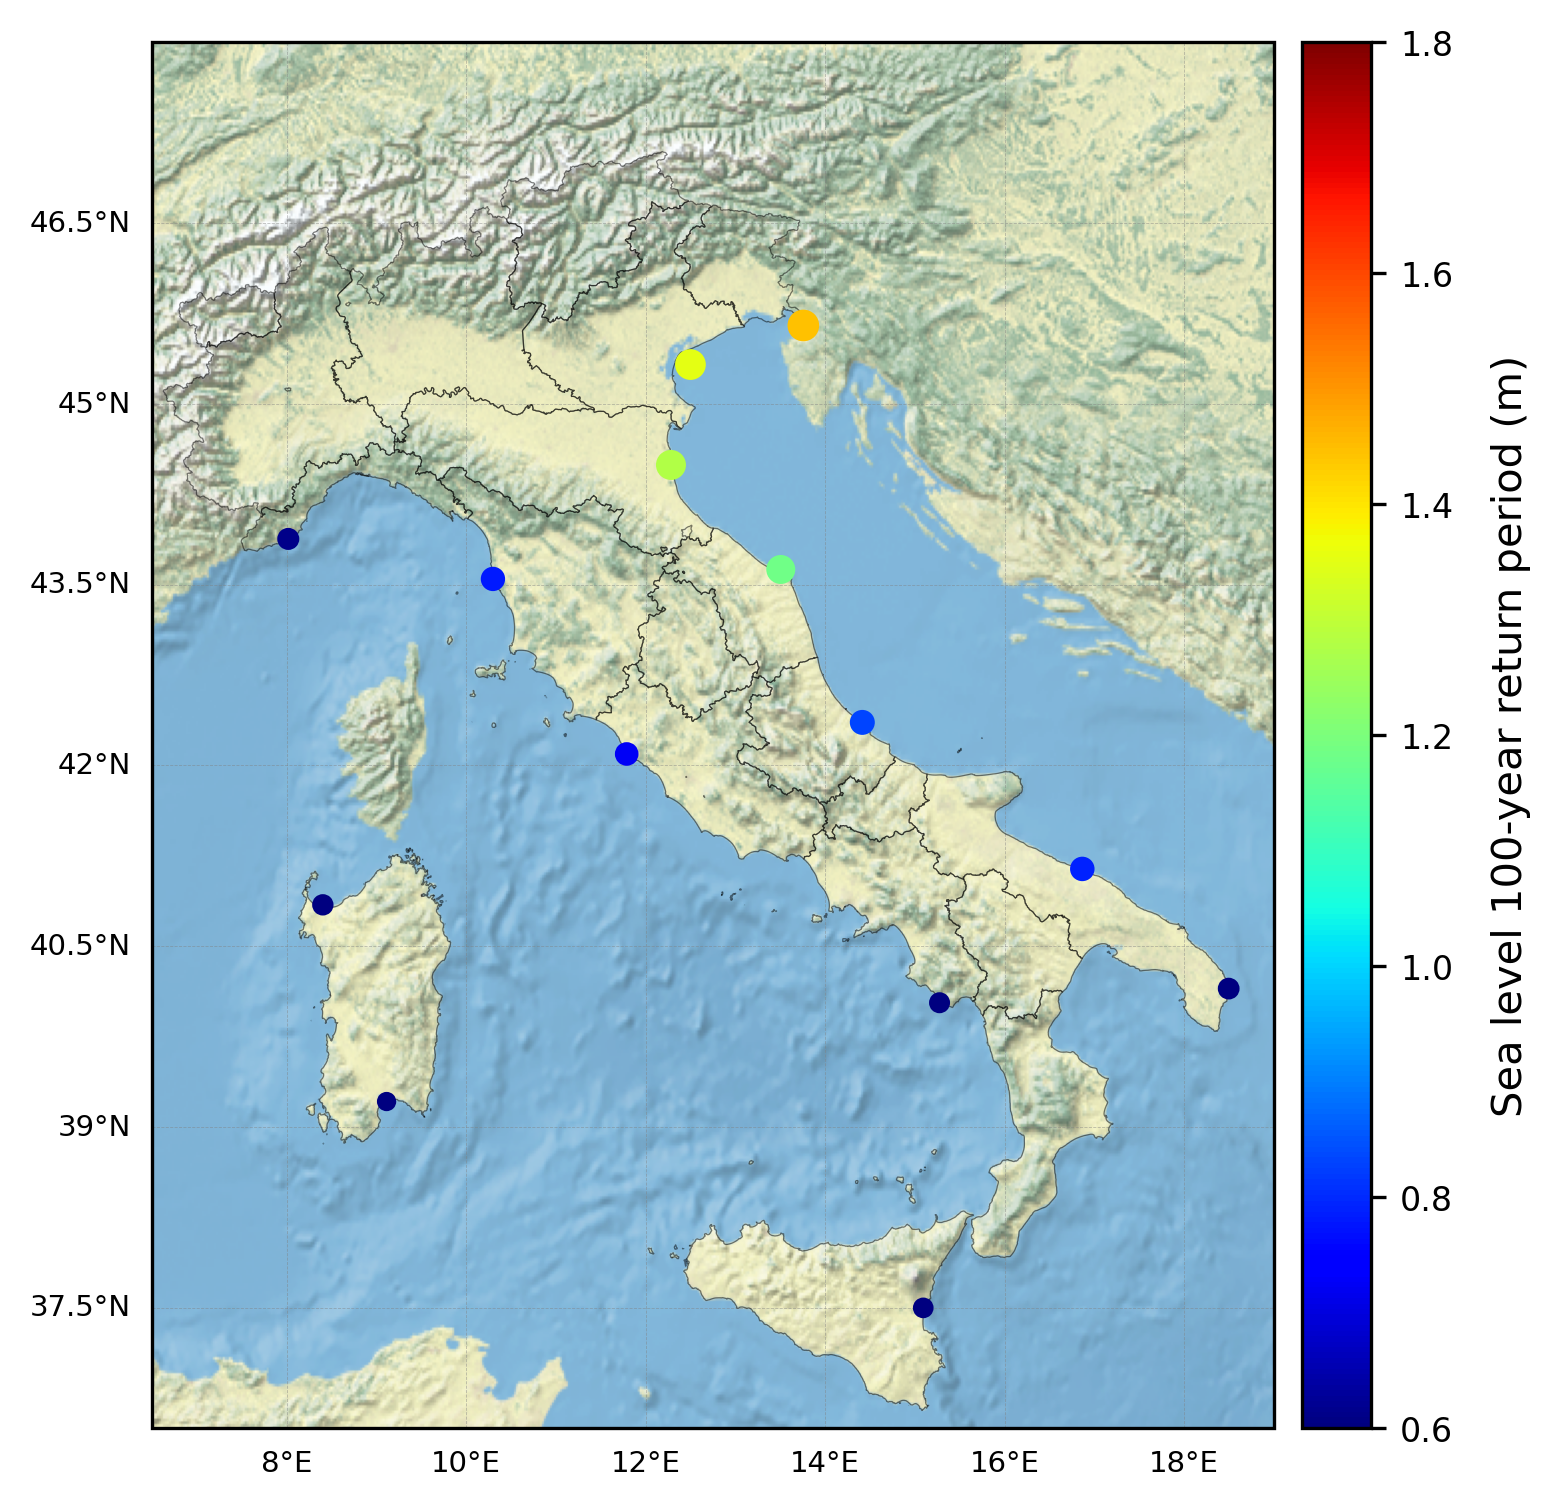

In [94]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(6,6),dpi=300)
gs = gridspec.GridSpec(1,1)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
# ax1.add_feature(cfeature.COASTLINE, linewidth=0.1, zorder=21, alpha=0.5)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.set_aspect('auto')

show(naturalearth, ax=ax1)

GEOMETRY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)

a1 = ax1.scatter(LON, LAT, s=MEV*30, c=MEV, cmap=Mev_cmap, norm=None, zorder=30, vmin=0.6, vmax=1.8)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

cbar = plt.colorbar(a1, fraction=0.05, pad=0.02, ticks=None)
cbar.ax.tick_params(labelsize=8)
cbar.set_label(f"Sea level 100-year return period (m)", fontsize=10, labelpad=9)
